# MOD510: Project 4

**Deadline: 01. December 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1: Stochastic modeling of mixing tanks


## Part 1: Single Mixing Tank with Parameter Uncertainty 

### Task 1

$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C$$

Solve using integration factor:

$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V}C \quad \Rightarrow \quad \frac{dC}{dt} + \frac{Q_{out}}{V}C = \frac{Q_{in}}{V} C_{in} \quad \Rightarrow \quad \frac{dC}{dt} + P(t)C = Q(t)$$

Find the integrating factor:

$$I(t) = \exp\left(\int P(t) \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\int \frac{Q_{out}}{V} \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\frac{Q_{out}}{V}t\right)$$

Now solve ODE using $I(t)$

$$C(t) = \frac{1}{I(t)}\left( \int I(t) Q(t) \text{ dt}\right) \quad \Rightarrow \quad C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt}\right)$$

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left(\frac{1}{\frac{Q_{out}}{V}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K \right)$$

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left(\frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in}+ K\right) \quad \Rightarrow \quad C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left(\frac{\cancel{V}}{Q_{out}} \cancel{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \frac{Q_{in}}{\cancel{V}} C_{in} + K\right)$$

$$C(t) = \frac{K}{\exp\left( \frac{Q_{out}}{V}t\right)} + \frac{Q_{in}}{Q_{out}}C_{in} \quad \Rightarrow \quad C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} $$

### Task 2

Setting: 

$V = \overline{V} = 1000 \text{ L}$

$Q_{out} = \overline{Q}_{out} = 100 \text{ L/s}$

$Q_{in} = \overline{Q}_{in} = 100 \text{ L/s}$

$C_{in} = \overline{C}_{in} = 0.25 \text{ g/L}$

$C(0) = \overline{C}_0 = 3.5 \text{ g/L}$

Find $K$:

$$ C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} \quad \Rightarrow \quad C(0) = K e^{- \frac{100 \text{ L/s}}{1000 \text{ L}} \cdot 0 \text{ s}} + \frac{100 \text{ L/s}}{100 \text{ L/s}} \cdot 0.25 \text{ g/L} $$

$$K e^{0} + 0.25 \text{ g/L} = 3.5 \text{ g/L} \quad \Rightarrow \quad K = 3.5\text{ g/L} - 0.25 \text{ g/L} \quad \Rightarrow \quad K = 3.25\text{ g/L}$$

With $t$ in seconds, the expression yields $C(t)$ in g/L:

$$C(t)= 3.25 \cdot e^{-0.1t} + 0.25$$

### Task 3

With $Q_{out} = 100 \text{ L/s}$ and $V = 1000 \text{ L}$:

$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t} \quad \Rightarrow \quad p = 1 - e^{-0.1 \Delta t}$$

### Task 4

In [11]:
import numpy as np
from numpy import random as rnd

r_seed = 18
n_runs = 100
n_steps = 1000
dt = 0.1
concentration_history = np.zeros((n_runs, n_steps))

for run in range(n_runs):
    v = rnd.uniform(950, 1050)
    q_out = q_in = rnd.uniform(95, 105)
    c_in = 0.0
    c = rnd.uniform(3.4, 3.6)

    for t in range(n_steps):
        p = 1 - np.exp((-q_out / v) * dt)
        c = c * (1 - p) + c_in * p
        concentration_history[run, t] = c

c_mean_op1 = np.mean(concentration_history, axis = 0)
c_std_op1 = np.std(concentration_history, axis = 0)
ci_lower_op1 = c_mean_op1- 1.96 * (c_std_op1 / np.sqrt(n_runs))
ci_upper_op1 = c_mean_op1 + 1.96 * (c_std_op1 / np.sqrt(n_runs))

### Task 5

In [12]:
r_seed = 18
n_runs = 100
n_steps = 1000
dt = 0.1
concentration_history = np.zeros((n_runs, n_steps))

for run in range(n_runs):
    v = rnd.uniform(950, 1050)
    c = rnd.uniform(3.4, 3.6)

    for t in range(n_steps):
        q_out = q_in = rnd.uniform(95, 105)
        c_in = 0.0
        p = 1 - np.exp((-q_out / v) * dt)
        c = c * (1 - p) + c_in * p
        concentration_history[run, t] = c

c_mean_op2 = np.mean(concentration_history, axis = 0)
c_std_op2 = np.std(concentration_history, axis = 0)
ci_lower_op2 = c_mean_op2 - 1.96 * (c_std_op2 / np.sqrt(n_runs))
ci_upper_op2 = c_mean_op2 + 1.96 * (c_std_op2 / np.sqrt(n_runs))

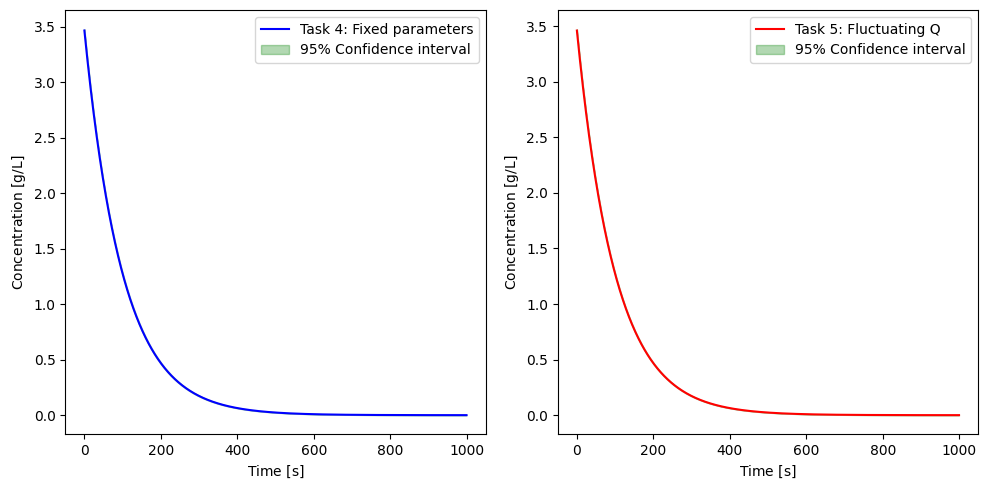

In [13]:
import matplotlib.pyplot as plt
time = np.arange(n_steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(time, c_mean_op1, color = 'blue',label = 'Task 4: Fixed parameters')
plt.fill_between(time, ci_lower_op1, ci_upper_op1, alpha=0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')


plt.subplot(1, 2, 2)
plt.plot(time, c_mean_op2, color = 'red', label = 'Task 5: Fluctuating Q')
plt.fill_between(time, ci_lower_op2, ci_upper_op2, alpha=0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.tight_layout()
plt.show()

In [14]:
width_op1 = ci_upper_op1 - ci_lower_op1
width_op2 = ci_upper_op2 - ci_lower_op2

mean_width_op1 = np.mean(width_op1)
mean_width_op2 = np.mean(width_op2)

print(f'Mean width option 1: {mean_width_op1:.7f}')
print(f'Mean width option 2: {mean_width_op2:.7f}')
print(f'Fixed parameters are {mean_width_op1/ mean_width_op2:.4f} times more uncertain')

Mean width option 1: 0.0058541
Mean width option 2: 0.0048394
Fixed parameters are 1.2097 times more uncertain


## Part 2

In [15]:
import numpy as np
from numpy import random as rnd

r_seed = 18
n_runs = 100
n_steps = 1000
dt = 0.1
concentration_1_history = np.zeros((n_runs, n_steps))
concentration_2_history = np.zeros((n_runs, n_steps))
concentration_3_history = np.zeros((n_runs, n_steps))

for run in range(n_runs):
    v = rnd.uniform(950, 1050)
    q_out = q_in = rnd.uniform(95, 105)
    c_in = 0.0
    c1 = rnd.uniform(3.4, 3.6)
    c2 = rnd.uniform(0, 0.1)
    c3 = rnd.uniform(0, 0.1)

    for t in range(n_steps):
        p = 1 - np.exp((-q_out / v) * dt)
        c1 = c1 * (1 - p) + c_in * p
        c2 = c2 * (1 - p) + c1 * p
        c3 = c3 * (1 - p) + c2 * p
        concentration_1_history[run, t] = c1
        concentration_2_history[run, t] = c2
        concentration_3_history[run, t] = c3

c_mean_1= np.mean(concentration_1_history, axis = 0)
c_std_1 = np.std(concentration_1_history, axis = 0)
ci_lower_1 = c_mean_1- 1.96 * (c_std_1 / np.sqrt(n_runs))
ci_upper_1 = c_mean_1 + 1.96 * (c_std_1 / np.sqrt(n_runs))

c_mean_2= np.mean(concentration_2_history, axis = 0)
c_std_2 = np.std(concentration_2_history, axis = 0)
ci_lower_2 = c_mean_2- 1.96 * (c_std_2 / np.sqrt(n_runs))
ci_upper_2 = c_mean_2 + 1.96 * (c_std_2 / np.sqrt(n_runs))

c_mean_3= np.mean(concentration_3_history, axis = 0)
c_std_3 = np.std(concentration_3_history, axis = 0)
ci_lower_3 = c_mean_3 - 1.96 * (c_std_3 / np.sqrt(n_runs))
ci_upper_3 = c_mean_3 + 1.96 * (c_std_3 / np.sqrt(n_runs))

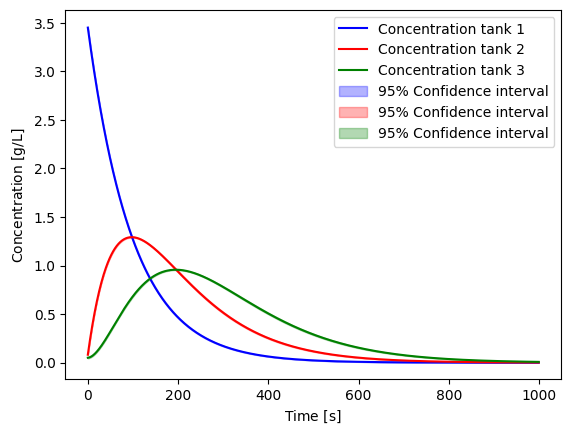

In [16]:
plt.plot(time, c_mean_1, color = 'blue', label = 'Concentration tank 1')
plt.plot(time, c_mean_2, color = 'red', label = 'Concentration tank 2')
plt.plot(time, c_mean_3, color = 'green', label = 'Concentration tank 3')
plt.fill_between(time, ci_lower_1, ci_upper_1, alpha=0.3, color = 'blue', label = "95% Confidence interval")
plt.fill_between(time, ci_lower_2, ci_upper_2, alpha=0.3, color = 'red', label = "95% Confidence interval")
plt.fill_between(time, ci_lower_3, ci_upper_3, alpha=0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.show()